<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/Serie_de_tiempo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalación de paquetes

In [1]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 5.0 MB/s eta 0:00:00


In [2]:
!pip install pydynpd

# Carga de Datos

In [3]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re

BASE = "https://www.latinobarometro.org"
INDEX = f"{BASE}/agregados"

headers = {
    "User-Agent": "Mozilla/5.0"
}

# =========================
# 1. obtener páginas de cada ola
# =========================

html = requests.get(INDEX, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

wave_pages = []

for a in soup.find_all("a", href=True):

    href = a["href"]

    # links tipo /latinobarometro-2023
    if re.search(r"latinobarometro-\d{4}$", href):

        full = urljoin(BASE, href)
        wave_pages.append(full)

wave_pages = sorted(set(wave_pages))

print("Olas encontradas:")
for w in wave_pages:
    print(w)

# =========================
# 2. entrar a cada ola y buscar ZIP de Stata
# =========================

stata_links = []

for page in wave_pages:

    print(f"\nRevisando {page}")

    try:
        html = requests.get(page, headers=headers, timeout=20).text
        soup = BeautifulSoup(html, "html.parser")

        for a in soup.find_all("a", href=True):

            href = a["href"]
            text = a.get_text(" ", strip=True).lower()

            full = urljoin(page, href)

            # queremos ZIPs relacionados con Stata
            if (
                ".zip" in href.lower()
                and (
                    "stata" in href.lower()
                    or "dta" in href.lower()
                    or "stata" in text
                )
            ):
                stata_links.append(full)

    except Exception as e:
        print("Error:", e)

# limpiar duplicados
stata_links = sorted(set(stata_links))

print("\nZIPs Stata encontrados:\n")

for l in stata_links:
    print(l)

Olas encontradas:
https://www.latinobarometro.org/latinobarometro-1995
https://www.latinobarometro.org/latinobarometro-1996
https://www.latinobarometro.org/latinobarometro-1997
https://www.latinobarometro.org/latinobarometro-1998
https://www.latinobarometro.org/latinobarometro-2000
https://www.latinobarometro.org/latinobarometro-2001
https://www.latinobarometro.org/latinobarometro-2002
https://www.latinobarometro.org/latinobarometro-2003
https://www.latinobarometro.org/latinobarometro-2004
https://www.latinobarometro.org/latinobarometro-2005
https://www.latinobarometro.org/latinobarometro-2006
https://www.latinobarometro.org/latinobarometro-2007
https://www.latinobarometro.org/latinobarometro-2008
https://www.latinobarometro.org/latinobarometro-2009
https://www.latinobarometro.org/latinobarometro-2010
https://www.latinobarometro.org/latinobarometro-2011
https://www.latinobarometro.org/latinobarometro-2013
https://www.latinobarometro.org/latinobarometro-2015
https://www.latinobarometro.

In [4]:
import requests

import shutil
import os

# borrar carpeta rota
shutil.rmtree("latinobarometro", ignore_errors=True)

# recrear
os.makedirs("latinobarometro", exist_ok=True)

for link in stata_links:

    filename = link.split("/")[-1]
    filepath = os.path.join("latinobarometro", filename)

    print("Descargando:", filename)

    r = requests.get(link)

    with open(filepath, "wb") as f:
        f.write(r.content)

Descargando: latinobarometro-1995-dta.zip
Descargando: latinobarometro-1996-dta.zip
Descargando: latinobarometro-1997-dta.zip
Descargando: latinobarometro-1998-dta.zip
Descargando: latinobarometro-2000-dta.zip
Descargando: latinobarometro-2001-dta.zip
Descargando: latinobarometro-2002-dta.zip
Descargando: latinobarometro-2003-dta.zip
Descargando: latinobarometro-2004-dta.zip
Descargando: latinobarometro-2005-dta.zip
Descargando: latinobarometro-2006-dta.zip
Descargando: latinobarometro-2007-dta.zip
Descargando: latinobarometro-2008-dta.zip
Descargando: latinobarometro-2009-dta.zip
Descargando: latinobarometro-2010-dta.zip
Descargando: latinobarometro-2011-dta.zip
Descargando: latinobarometro-2013-dta.zip
Descargando: latinobarometro-2015-dta.zip
Descargando: latinobarometro2016-dta.zip
Descargando: latinobarometro2017-dta.zip
Descargando: latinobarometro-2018-eng-stata-v20190303.zip
Descargando: latinobarometro-2018-esp-dta-v20190303.zip
Descargando: latinobarometro-2020-eng-stata-v1-0

In [5]:
!mkdir -p latinobarometro/unzipped

!find latinobarometro -name "*.zip" -exec unzip -o {} -d latinobarometro/unzipped \;

Archive:  latinobarometro/latinobarometro-2018-esp-dta-v20190303.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2018_Esp_Stata_v20190303.dta  
Archive:  latinobarometro/latinobarometro-2010-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2010_eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2010_esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2010_datos_esp_v2014_06_27.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_2010_datos_eng_v2014_06_27.dta  
Archive:  latinobarometro/latinobarometro2017-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro2017Eng_v20180117.dta  
  inflating: latinobarometro/unzipped/Latinobarometro2017Esp_v20180117.dta  
  inflating: latinobarometro/unzipped/Latinobarometro2017_Cuestionario_Esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro2017_Questionnaire_Eng.pdf  
Archive:  latinobarometro/latinobarometro-2000-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro

In [6]:
# =========================
# mapeo armonizado
# =========================

varmap = {

    # ---------------------------------
    # satisfacción con la vida
    # ---------------------------------

    "life_satisfaction": {

        1997: "nsp10",
        2000: "P8ST",
        2001: "p41st",
        2002: "p1wvs",
        2003: "p19st",
        2004: "p1st",
        2005: "p1st",
        2006: "p1st_a",
        2007: "p1st",
        2008: "p27st",
        2009: "p1st",
        2010: "P1ST",
        2011: "P1ST",
        2013: "P1ST",
        2015: "P1ST",
        2016: "P1ST",
        2017: "P1ST",
        2018: "P1STC",
        2020: "p1st",
        2023: "P1ST",
        2024: "P1ST"
    },


    # ---------------------------------
    # situación económica actual del país
    # ---------------------------------

    "econ_country": {

        1995: "p1",
        1996: "p1",
        1997: "sp1",
        1998: "sp1",
        2000: "P1ST",
        2001: "p1st",
        2002: "p2sta",
        2003: "p1st",
        2004: "p2st",
        2005: "p2st",
        2006: "p2st",
        2007: "p100st",
        2008: "p4st",
        2009: "p3st_a",
        2010: "P3ST_A",
        2011: "P3ST_A",
        2013: "P3STGBS",
        2015: "P3STGBS",
        2016: "P4STGBS",
        2017: "P4STGBSC",
        2018: "P6STGBSC",
        2020: "p4stgbs",
        2023: "P5STGBS",
        2024: "P6STGBS"
    },

    # ---------------------------------
    # confianza interpersonal
    # ---------------------------------

    "trust_people": {

        1996: "p12",
        1997: "sp21",
        1998: "sp20",
        2000: "P17ST",
        2001: "p42st",
        2002: "p29st",
        2003: "p20st",
        2004: "p43st",
        2005: "p14st",
        2006: "p45st",
        2007: "p23st",
        2008: "p21wvsst",
        2009: "p58st",
        2010: "P55ST",
        2011: "P25ST",
        2013: "P29STGBS",
        2015: "P15STGBS",
        2016: "P12STGBS",
        2017: "P13STGBS",
        2018: "P11STGBS",
        2020: "p9stgbs",
        2023: "P9STGBS",
        2024: "P10STGBS"
    },

    # ---------------------------------
    # ciudad
    # ---------------------------------

    "city": {
        1997: "ciudad",
        2000: "ciudad",
        2001: "ciudad",
        2003: "ciudad",
        2004: "Ciudad",
        2005: "ciudad",
        2006: "ciudad",
        2007: "ciudad",
        2008: "ciudad",
        2009: "ciudad",
        2010: "ciudad",
        2011: "ciudad",
        2013: "ciudad",
        2015: "ciudad",
        2016: "ciudad",
        2017: "ciudad",
        2018: "CIUDAD",
        2020: "ciudad",
        2023: "ciudad",
        2024: "CIUDAD"
    },

    # ---------------------------------
    # interés en política
    # ---------------------------------

    "interest_politics": {

        1995: "p62",
        1996: "p64",
        1997: "sp41",
        1998: "sp36",
        2000: "P63ST",
        2001: "p56st",
        2003: "p61st",
        2004: "p29st",
        2005: "p37st",
        2007: "p59st",
        2009: "p32st",
        2010: "P23ST",
        2013: "P20STGBS",
        2020: "p46stgbs",
        2023: "P40STGBS",
        2024: "P36STGBS",

    },

    # ---------------------------------
    # sexo
    # ---------------------------------

    "sex": {

        1995: "s1",
        1996: "s1",
        1997: "s1",
        1998: "s1",
        2000: "S1",
        2001: "s1",
        2002: "s1",
        2003: "s1",
        2004: "s1",
        2005: "s6",
        2006: "s6",
        2007: "s10",
        2008: "s8",
        2009: "s5",
        2010: "S7",
        2011: "S16",
        2013: "S10",
        2015: "S12",
        2016: "sexo",
        2017: "sexo",
        2018: "SEXO",
        2020: "sexo",
        2023: "sexo",
        2024: "SEXO"
    },

    # ---------------------------------
    # edad
    # ---------------------------------

    "age": {

        1995: "s2",
        1996: "s2",
        1997: "s2",
        1998: "s2",
        2000: "S2",
        2001: "s2",
        2002: "s2",
        2003: "s2",
        2004: "s2",
        2005: "s7",
        2006: "s7",
        2007: "s11",
        2008: "s9",
        2009: "s6",
        2010: "S8",
        2011: "S17",
        2013: "S11",
        2015: "S13",
        2016: "edad",
        2017: "edad",
        2018: "EDAD",
        2020: "edad",
        2023: "edad",
        2024: "EDAD"
    },

    # ---------------------------------
    # estado civil
    # ---------------------------------

    "civil_status": {

        1995: "s6",
        1996: "s5",
        1997: "s5",
        1998: "s5",
        2000: "S4",
        2001: "s4",
        2002: "s4",
        2003: "s4",
        2004: "s4",
        2005: "s9",
        2006: "s9",
        2007: "s13",
        2008: "s3",
        2009: "s3",
        2010: "S5",
        2011: "S15",
        2013: "S9",
        2015: "S11",
        2016: "S5",
        2017: "S6",
        2018: "S23"
    },

    # ---------------------------------
    # izquierda-derecha
    # ---------------------------------

    "left_right": {

        1995: "p31",
        1996: "p38",
        1997: "sp56",
        1998: "sp52",
        2000: "P52ST",
        2001: "p54st",
        2002: "p64st",
        2003: "p60st",
        2004: "p87st",
        2005: "p34st",
        2006: "p47st",
        2007: "p67st",
        2008: "p56st",
        2009: "p69st",
        2010: "P60ST",
        2011: "P76ST",
        2013: "P41ST",
        2015: "P27ST",
        2016: "P17ST",
        2017: "P19STC",
        2018: "P22ST",
        2020: "p18st",
        2023: "P16ST",
        2024: "P16ST"
    },


    # ---------------------------------
    # país
    # ---------------------------------

    "country": {

        1995: "pais",
        1996: "pais",
        1997: "idenpa",
        1998: "idenpa",
        2000: "idenpa",
        2001: "idenpa",
        2002: "idenpa",
        2003: "idenpa",
        2004: "idenpa",
        2005: "idenpa",
        2006: "idenpa",
        2007: "idenpa",
        2008: "idenpa",
        2009: "idenpa",
        2010: "idenpa",
        2011: "idenpa",
        2013: "idenpa",
        2015: "idenpa",
        2016: "idenpa",
        2017: "idenpa",
        2018: "IDENPA",
        2020: "idenpa",
        2023: "idenpa",
        2024: "IDENPA"
    },

    # ---------------------------------
    # educación
    # ---------------------------------

"education": {

    1995: "s17",
    1996: "s14",
    1997: "s10",
    1998: "s11",
    2000: "S6",
    2001: "s6",
    2002: "s6",
    2003: "s6",
    2004: "s6",
    2005: "s11",
    2006: "s11",
    2007: "s15",
    2008: "s15",
    2009: "s12",
    2010: "S14",
    2011: "S21",
    2013: "S17",
    2015: "S19",
    2016: "S13",
    2017: "S14",
    2018: "S10",
    2020: "s16",
    2023: "S11",
    2024: "S11"
},

# ---------------------------------
# twitter
# ---------------------------------

"twitter": {

    2009: "S25_E",
    2010: "S27_E",
    2011: "S33ST_BE",
    2013: "P83TNCE",
    2015: "S10M_E",
    2016: "S15M_D",
    2017: "S16M_D",
    2018: "S12M.D",
    2020: "s19m_04",
    2023: "S14M_D",
    2024: "S14M.4"

},

# ---------------------------------
# Voto
# ---------------------------------
"vote": {

    1995: "p33",
    1996: "p40",
    1997: "sp58",
    1998: "sp53",
    2000: "P54ST",
    2001: "p55st",
    2002: "p45st",
    2003: "p54st",
    2004: "p30st",
    2005: "p48st",
    2006: "p38st",
    2007: "p64st",
    2008: "p61st",
    2009: "p35st",
    2010: "P29ST",
    2011: "P38ST",
    2013: "P22TGBSM",
    2015: "P23TGBSM",
    2016: "P15STGBS",
    2017: "P16STGBS",
    2018: "P21STGBS.A",
    2020: "P50STGBS_A",
    2023: "P43STGBS_A",
    2024: "P39STGBS.A"
}

}

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path("latinobarometro/unzipped")

# =========================
# buscar archivos
# =========================

dta_files = sorted([
    f for f in BASE.rglob("*.dta")
    if "eng" not in f.name.lower()
])

# =========================
# detectar ola
# =========================

def detect_wave(path):

    m = re.search(r"(19|20)\d{2}", path.name)

    if m:
        return int(m.group())

    return np.nan

# =========================
# verificar SOLO faltantes
# =========================

for file in dta_files:

    try:

        wave = detect_wave(file)

        # leer pocas filas
        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        existing_cols = set(tmp.columns)

        missing = []

        # -------------------------
        # revisar varmap
        # -------------------------

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var not in existing_cols:

                missing.append(
                    f"{new_name} -> {old_var}"
                )

        # -------------------------
        # imprimir sólo si faltan
        # -------------------------

        if len(missing) > 0:

            print("\n" + "="*60)
            print(f"{file.name} | wave={wave}")

            for m in missing:
                print("FALTA:", m)

        del tmp
        del tmp_reader

    except Exception as e:

        print(f"\nERROR en {file.name}")
        print(e)

In [8]:
# =========================================
# buscar la variable de Twitter por año
# =========================================

social_blocks = {
    2009: "S25",
    2010: "S27",
    2011: "S33ST",
    2013: "P83TNC",
    2015: "S10M",
    2016: "S15M",
    2017: "S16M",
    2018: "S12M",
    2020: "S19M",
    2023: "S14M"
}

for file in dta_files:

    wave = detect_wave(file)

    if wave not in social_blocks:
        continue

    bloque = social_blocks[wave]

    try:

        reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        var_labels = reader.variable_labels()

        print("\n" + "="*70)
        print(file.name, "| wave =", wave)

        for var, label in var_labels.items():

            if var.upper().startswith(bloque.upper()):

                if "twitter" in str(label).lower():

                    print("VARIABLE:", var)
                    print("LABEL:", label)

    except Exception as e:

        print("\nERROR:", file.name)
        print(e)


Latinobarometro2013.dta | wave = 2013
VARIABLE: P83TNCE
LABEL: P83TNCE Uso redes sociales: Twitter

Latinobarometro2016Esp_v20170205.dta | wave = 2016
VARIABLE: S15M_D
LABEL: S15M_D Uso redes sociales: Twitter

Latinobarometro2017Esp_v20180117.dta | wave = 2017
VARIABLE: S16M_D
LABEL: S16M_D Uso redes sociales: Twitter

Latinobarometro_2009_datos_esp_v2014_06_27.dta | wave = 2009
VARIABLE: S25_E
LABEL: Servicios de Redes Sociales utilizados: Twitter

Latinobarometro_2010_datos_esp_v2014_06_27.dta | wave = 2010
VARIABLE: S27_E
LABEL: Servicios de Redes Sociales utilizados: Twitter

Latinobarometro_2011_esp.dta | wave = 2011
VARIABLE: S33ST_BE
LABEL: Servicios de Redes Sociales utilizados: Twitter

Latinobarometro_2015_Esp.dta | wave = 2015
VARIABLE: S10M_E
LABEL: S10M_E Uso redes sociales: Twitter

Latinobarometro_2018_Esp_Stata_v20190303.dta | wave = 2018
VARIABLE: S12M.D
LABEL: S12M.D Redes sociales que utiliza: Twitter

Latinobarometro_2020_Esp_Stata_v1_0.dta | wave = 2020
VARIABLE:

In [9]:
def detect_id(df):

    for c in [
        "IDNUM",
        "idnum",
        "Idnum",
        "id_num",
        "NUMINVES",
        "numinves",
        "folio",
        "FOLIO",
        "numero",
        "NUMERO"
    ]:

        if c in df.columns:
            return c

    return None

# =========================
# merge final
# =========================

master = pd.DataFrame()

for file in dta_files:

    try:

        wave = detect_wave(file)

        print(f"Cargando {file.name} | wave={wave}")

        # -------------------------
        # leer nombres columnas
        # -------------------------

        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        # normalizar nombres
        tmp.columns = (
            tmp.columns
            .str.strip()
        )

        existing_cols = set(tmp.columns)

        # -------------------------
        # detectar ID
        # -------------------------

        id_col = detect_id(tmp)

        if id_col is None:

            print("  -> no se encontró ID")
            continue

        # -------------------------
        # variables disponibles
        # -------------------------

        wave_vars = {}

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var in existing_cols:

                wave_vars[new_name] = old_var

        # columnas a leer
        cols_to_read = list(
            set(wave_vars.values()) | {id_col}
        )

        # -------------------------
        # cargar datos reales
        # -------------------------

        df = pd.read_stata(
            file,
            columns=cols_to_read,
            convert_categoricals=False
        )

        # normalizar columnas
        df.columns = (
            df.columns
            .str.strip()
        )

        # -------------------------
        # crear ID
        # -------------------------

        df["id"] = df[id_col].astype(str)

        # -------------------------
        # renombrar variables
        # -------------------------

        rename_dict = {
            old: new
            for new, old in wave_vars.items()
        }

        df = df.rename(columns=rename_dict)

        # -------------------------
        # agregar ola
        # -------------------------

        df["wave"] = wave

        # -------------------------
        # conservar columnas finales
        # -------------------------

        keep_cols = [
            "id",
            "wave",
            "country",
            "city",
            "life_satisfaction",
            "interest_politics",
            "sex",
            "age",
            "civil_status",
            "left_right",
            "education",
            "econ_country",
            "trust_people",
            "twitter",
            "vote"
        ]

        # crear faltantes
        for c in keep_cols:

            if c not in df.columns:
                df[c] = np.nan

        df = df[keep_cols]

        # -------------------------
        # append
        # -------------------------

        master = pd.concat(
            [master, df],
            ignore_index=True,
            sort=False
        )

        del df
        del tmp
        del tmp_reader

    except Exception as e:

        print(f"ERROR en {file.name}")
        print(e)

Cargando Latinobarometro2013.dta | wave=2013
Cargando Latinobarometro2016Esp_v20170205.dta | wave=2016
Cargando Latinobarometro2017Esp_v20180117.dta | wave=2017
Cargando Latinobarometro_1995_datos_esp_v2014_06_27.dta | wave=1995
Cargando Latinobarometro_1996_datos_esp_v2014_06_27.dta | wave=1996
Cargando Latinobarometro_1997_datos_esp_v2014_06_27.dta | wave=1997
Cargando Latinobarometro_1998_datos_esp_v2014_06_27.dta | wave=1998
Cargando Latinobarometro_2000_datos_esp_v2014_06_27.dta | wave=2000
Cargando Latinobarometro_2001_datos_esp_v2014_06_27.dta | wave=2001
Cargando Latinobarometro_2002_datos_esp_v2014_06_27.dta | wave=2002
Cargando Latinobarometro_2003_datos_esp_v2014_06_27.dta | wave=2003
Cargando Latinobarometro_2004_datos_esp_v2014_06_27.dta | wave=2004
Cargando Latinobarometro_2005_datos_esp_v2014_06_27.dta | wave=2005
Cargando Latinobarometro_2006_datos_esp_v2014_06_27.dta | wave=2006
Cargando Latinobarometro_2007_datos_esp_v2014_06_27.dta | wave=2007
Cargando Latinobarometr

# Redodificación

In [10]:
# =========================
# recodificar life_satisfaction
# =========================

conversion = {

    4: 1,  # para nada
    3: 2,  # no muy
    2: 3,  # bastante
    1: 4   # muy
}

master["life_satisfaction"] = (
    master["life_satisfaction"]
    .map(conversion)
)

# =========================
# recodificar interest_politics
# =========================

master["interest_politics"] = (
    master["interest_politics"]
    .replace(conversion)
)

# =========================
# recodificar sex
# =========================

conversion = {
    1: 1,  # hombre
    2: 0   # mujer
}

master["sex"] = (
    master["sex"]
    .map(conversion)
)

# =========================
# distancia al centro ideológico
# =========================

def convertir(val):

    try:

        num = float(val)

        # missings típicos latinobarómetro
        if num in [97, 98, 99, -1, -2, -6, -8]:
            return np.nan

        return num

    except:

        return np.nan

# convertir escala izquierda-derecha
master["left_right_scale"] = (
    master["left_right"]
    .apply(convertir)
)

# distancia al centro
master["left_right_distance"] = (
    np.abs(master["left_right_scale"] - 5)
)

master["polarization"]=master["left_right_distance"]

# =========================
# recodificar education
# =========================

# paso 1
master["education_num"] = pd.to_numeric(
    master["education"],
    errors="coerce"
)

# paso 2
def escalar_educacion(x):

    if pd.isna(x):
        return np.nan

    if x == 1:
        return 0  # sin estudios

    elif 2 <= x <= 13:
        return x - 1  # años reales

    elif x == 14:
        return 14  # universitario incompleto

    elif x == 15:
        return 16  # universitario completo

    elif x == 16:
        return 13  # técnico incompleto

    elif x == 17:
        return 14  # técnico completo

    else:
        return np.nan

# aplicar
master["education"] = (
    master["education_num"]
    .apply(escalar_educacion)
)


# =========================
# recodificar econ_country
# =========================

master["econ_country"] = pd.to_numeric(
    master["econ_country"],
    errors="coerce"
)

conversion_econ = {

    1: 5,  # muy buena
    2: 4,  # buena
    3: 3,  # regular
    4: 2,  # mala
    5: 1   # muy mala
}

master["econ_country"] = (
    master["econ_country"]
    .map(conversion_econ)
)

# =========================
# recodificar trust_people
# =========================

conversion = {

    1: 1,  # se puede confiar
    2: 0   # nunca suficientemente cuidadoso
}

master["trust_people"] = pd.to_numeric(
    master["trust_people"],
    errors="coerce"
)

master["trust_people"] = (
    master["trust_people"]
    .map(conversion)
)

# cualquier valor no mapeado -> NaN
master.loc[
    ~master["trust_people"].isin([0, 1]),
    "trust_people"
] = np.nan

master["twitter"] = np.where(
    master["twitter"] == 1,
    1,
    np.where(
        master["twitter"] == 0,
        0,
        np.nan
    )
)

sin_partido = {
    -7, -4, -3, -2, -1,
    94, 95, 96, 97
}

master["party_id"] = (
    (~master["vote"].isin(sin_partido))
    & (master["vote"].notna())
).astype(int)

In [11]:
master["left_right_scale"].unique()

array([ 6.,  2.,  5.,  7., nan,  0.,  3.,  4.,  9., 10.,  8.,  1.])

# EDA

In [12]:
master["interest_politics"] = master["interest_politics"].replace(-2, np.nan)
master["interest_politics"] = master["interest_politics"].replace(-1, np.nan)


master["age"] = master["age"].replace(-2, np.nan)

master["civil_status"] = master["civil_status"].replace(-2, np.nan)

master["left_right"] = master["left_right"].replace(
    [-8, 97],
    np.nan
)

master["vote"] = master["vote"].replace(
    [-7, -1],
    np.nan
)

In [13]:
cols=["life_satisfaction",

      "interest_politics",
      "left_right_distance",
      "party_id",

      "sex",
      "age",
      "education",
      "econ_country",
      "trust_people",
      "twitter",
      ]

In [14]:
#Eliminamos España
master = master[master['country'] != 724]

In [15]:
master[cols].describe()

,life_satisfaction,interest_politics,left_right_distance,party_id,sex,age,education,econ_country,trust_people,twitter
count,409128.000000,292979.000000,363169.000000,457499.000000,457456.00000,457448.000000,453793.000000,454369.000000,435737.000000,218992.00000
mean,2.948816,2.003615,2.119738,0.405404,0.48416,39.728496,8.907524,2.573886,0.183707,0.09662
std,0.882332,0.964977,1.904596,0.490971,0.49975,16.312467,4.592784,0.931888,0.387246,0.29544
min,1.000000,1.000000,0.000000,0.000000,0.00000,15.000000,0.000000,1.000000,0.000000,0.00000
25%,2.000000,1.000000,0.000000,0.000000,0.00000,26.000000,6.000000,2.000000,0.000000,0.00000
50%,3.000000,2.000000,2.000000,0.000000,0.00000,37.000000,9.000000,3.000000,0.000000,0.00000
75%,4.000000,3.000000,4.000000,1.000000,1.00000,51.000000,12.000000,3.000000,0.000000,0.00000
max,4.000000,4.000000,5.000000,1.000000,1.00000,100.000000,16.000000,5.000000,1.000000,1.00000


In [16]:
master.groupby("wave")[cols].mean()

,life_satisfaction,interest_politics,left_right_distance,party_id,sex,age,education,econ_country,trust_people,twitter
wave,,,,,,,,,,
1995,NaN,2.028808,1.979335,0.487044,0.472554,38.732693,9.328120,2.503451,NaN,NaN
1996,NaN,1.924315,2.156100,0.457236,0.488481,38.530667,9.693843,2.313983,0.207621,NaN
1997,2.351060,2.106340,2.009398,0.407722,0.488208,38.204721,9.944578,2.518924,0.231819,NaN
1998,NaN,2.060431,2.039143,0.520769,0.486799,38.158461,10.163757,2.405340,0.215581,NaN
2000,2.365140,2.113045,1.964082,0.059486,0.486029,38.393724,9.943342,2.433088,0.158688,NaN
2001,2.905119,1.945218,2.227452,0.429777,0.490984,38.545354,8.687951,2.213270,0.177832,NaN
2002,2.848678,NaN,2.377912,0.053666,0.484181,38.748515,8.532664,2.312765,0.195586,NaN
2003,3.066789,1.959148,2.272369,0.405569,0.487660,38.984548,8.285385,2.274735,0.172515,NaN
2004,2.880672,2.029540,2.109285,0.074573,0.492629,38.949248,8.309411,2.360962,0.162253,NaN


In [17]:
import pandas as pd

# Estadísticas descriptivas
desc = master[cols].agg(
    ['mean', 'std', 'min', 'max', 'count']
).T

desc.columns = ['Mean', 'SD', 'Min', 'Max', 'N']

rows = [
    ("\\midrule\n\\multicolumn{6}{l}{\\textit{Variable dependiente}} \\\\", None),
    ("Satisfacción con la vida", "life_satisfaction"),

    ("\\midrule\n\\multicolumn{6}{l}{\\textit{Variables principales}} \\\\", None),
    ("Interés por la política", "interest_politics"),
    ("Polarización ideológica", "left_right_distance"),
    ("Se identifica con un partido", "party_id"),

    ("\\midrule\n\\multicolumn{6}{l}{\\textit{Características sociodemográficas}} \\\\", None),
    ("Sexo (hombre)", "sex"),
    ("Edad", "age"),
    ("Nivel educativo", "education"),

    ("\\midrule\n\\multicolumn{6}{l}{\\textit{Variables actitudinales}} \\\\", None),
    ("Eval. de la sit. econ. del país", "econ_country"),
    ("Confianza interpersonal", "trust_people"),

    ("\\midrule\n\\multicolumn{6}{l}{\\textit{Redes sociales}} \\\\", None),
    ("Uso de Twitter/X", "twitter"),
]

latex = []
latex.append("\\begin{table}[htbp]")
latex.append("\\centering")
latex.append("\\caption{Estadísticas descriptivas}")
latex.append("\\label{tab:descriptivas}")
latex.append("\\begin{tabular}{lccccc}")
latex.append("\\toprule")
latex.append("Variable & Media & DE & Mín. & Máx. & N \\\\")
latex.append("\\midrule")

for label, var in rows:

    if var is None:
        latex.append(label)
        continue

    r = desc.loc[var]

    latex.append(
        f"{label} & "
        f"{r['Mean']:.2f} & "
        f"{r['SD']:.2f} & "
        f"{r['Min']:.2f} & "
        f"{r['Max']:.2f} & "
        f"{int(r['N']):,} \\\\"
    )

latex.append("\\bottomrule")
latex.append("\\end{tabular}")
latex.append("\\end{table}")

with open("descriptive_stats.tex", "w", encoding="utf-8") as f:
    f.write("\n".join(latex))

In [18]:
vars_avail = {
    "life_satisfaction": "Felicidad",
    "interest_politics": "Interés político",
    "left_right": "Polarización",
    "education": "Educación",
    "trust_people": "Confianza",
    "twitter": "Twitter"
}

availability = (
    master
    .groupby("wave")
    .agg(
        Observaciones=("wave", "size"),
        Paises=("country", "nunique")
    )
)

for var, label in vars_avail.items():
    availability[label] = (
        master
        .groupby("wave")[var]
        .apply(lambda x: 100 * x.notna().mean())
    )

availability = availability.round(1)

In [19]:
latex = availability.to_latex(
    caption="Disponibilidad de información por ola",
    label="tab:availability",
    float_format="%.1f",
    escape=False
)

with open("availability.tex", "w", encoding="utf-8") as f:
    f.write(latex)

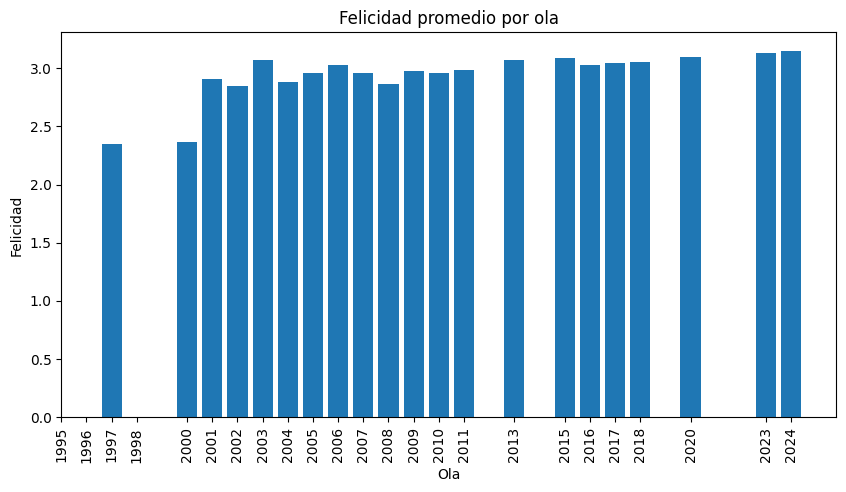

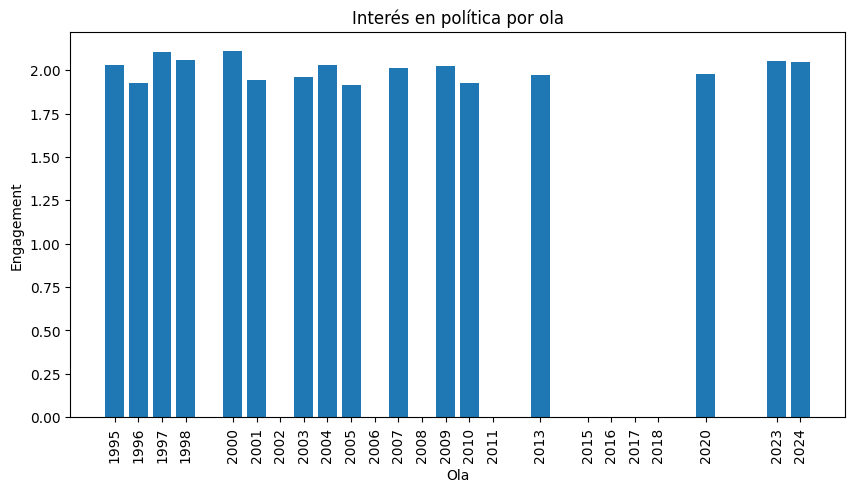

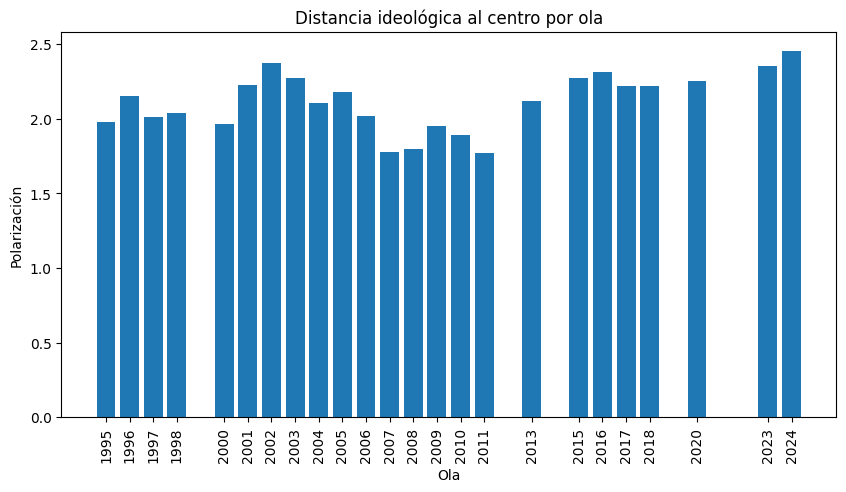

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# preparar datos
# =========================

yearly = (
    master
    .groupby("wave")[
        [
            "life_satisfaction",
            "interest_politics",
            "left_right_distance"
        ]
    ]
    .mean()
    .reset_index()
)

yearly = yearly.rename(columns={
    "life_satisfaction": "felicidad",
    "interest_politics": "engagement",
    "left_right_distance": "polarization"
})

# ordenar por wave por seguridad
yearly = yearly.sort_values("wave")

waves = yearly["wave"]

# =========================
# felicidad
# =========================

plt.figure(figsize=(10,5))

plt.bar(waves, yearly["felicidad"])

plt.title("Felicidad promedio por ola")
plt.xlabel("Ola")
plt.ylabel("Felicidad")

plt.xticks(waves, rotation=90)

plt.show()

# =========================
# engagement político
# =========================

plt.figure(figsize=(10,5))

plt.bar(waves, yearly["engagement"])

plt.title("Interés en política por ola")
plt.xlabel("Ola")
plt.ylabel("Engagement")

plt.xticks(waves, rotation=90)

plt.show()

# =========================
# polarización
# =========================

plt.figure(figsize=(10,5))

plt.bar(waves, yearly["polarization"])

plt.title("Distancia ideológica al centro por ola")
plt.xlabel("Ola")
plt.ylabel("Polarización")

plt.xticks(waves, rotation=90)

plt.show()

/tmp/ipykernel_2550/4157458528.py:75: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(


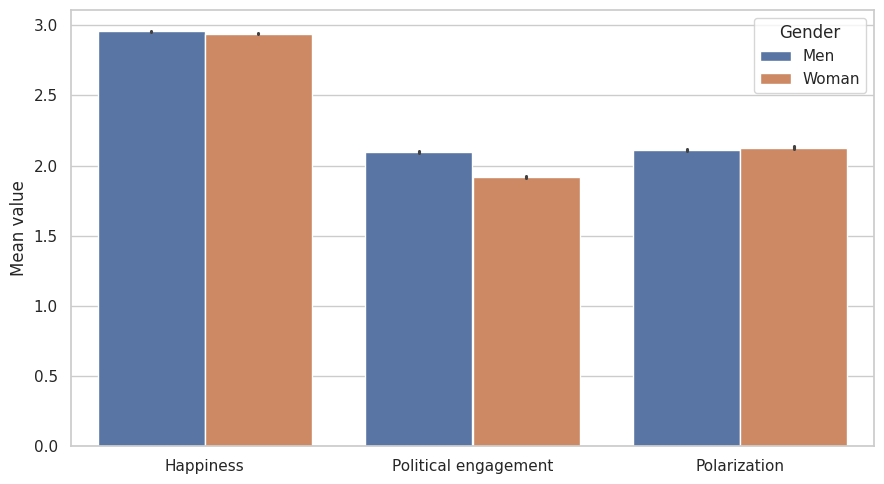

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------
# estilo
# ---------------------------------

sns.set_theme(style="whitegrid")

# ---------------------------------
# género
# ---------------------------------

gender_map = {
    1: "Men",
    0: "Woman"
}

# ---------------------------------
# elegir rango de años
# ---------------------------------

start_year = 1995
end_year = 2024

df_plot = master[
    (master["wave"] >= start_year) &
    (master["wave"] <= end_year)
].copy()

df_plot["gender_label"] = (
    df_plot["sex"]
    .map(gender_map)
)

# ---------------------------------
# variables
# ---------------------------------

vars_plot = [
    "life_satisfaction",
    "interest_politics",
    "left_right_distance"
]

labels_map = {
    "life_satisfaction": "Happiness",
    "interest_politics": "Political engagement",
    "left_right_distance": "Polarization"
}

# ---------------------------------
# formato largo
# ---------------------------------

df_melt = df_plot.melt(
    id_vars="gender_label",
    value_vars=vars_plot,
    var_name="variable",
    value_name="value"
)

df_melt["variable"] = (
    df_melt["variable"]
    .map(labels_map)
)

# ---------------------------------
# plot
# ---------------------------------

plt.figure(figsize=(9,5))

sns.barplot(
    data=df_melt,
    x="variable",
    y="value",
    hue="gender_label",
    errorbar=("ci", 95),
    palette=sns.color_palette("deep")
)

plt.xlabel("")
plt.ylabel("Mean value")

plt.legend(title="Gender")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2550/933078311.py:68: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.barplot(


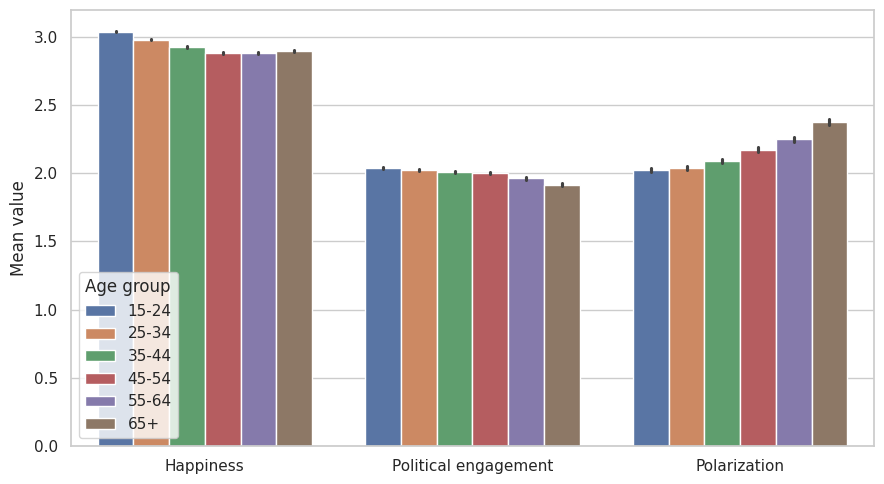

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# ---------------------------------
# rango de años
# ---------------------------------

start_year = 1995
end_year = 2024

df_plot = master[
    (master["wave"] >= start_year) &
    (master["wave"] <= end_year)
].copy()

# ---------------------------------
# crear grupos de edad
# ---------------------------------

age_bins = [15, 25, 35, 45, 55, 65, 100]
age_labels = ["15-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df_plot["age_group"] = pd.cut(
    df_plot["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# ---------------------------------
# variables
# ---------------------------------

vars_plot = [
    "life_satisfaction",
    "interest_politics",
    "left_right_distance"
]

labels_map = {
    "life_satisfaction": "Happiness",
    "interest_politics": "Political engagement",
    "left_right_distance": "Polarization"
}

# ---------------------------------
# formato largo
# ---------------------------------

df_melt = df_plot.melt(
    id_vars="age_group",
    value_vars=vars_plot,
    var_name="variable",
    value_name="value"
)

df_melt["variable"] = df_melt["variable"].map(labels_map)

# ---------------------------------
# plot
# ---------------------------------

plt.figure(figsize=(9,5))

sns.barplot(
    data=df_melt,
    x="variable",
    y="value",
    hue="age_group",
    errorbar=("ci", 95),
    palette=sns.color_palette("deep")
)

plt.xlabel("")
plt.ylabel("Mean value")
plt.legend(title="Age group")

plt.tight_layout()
plt.show()

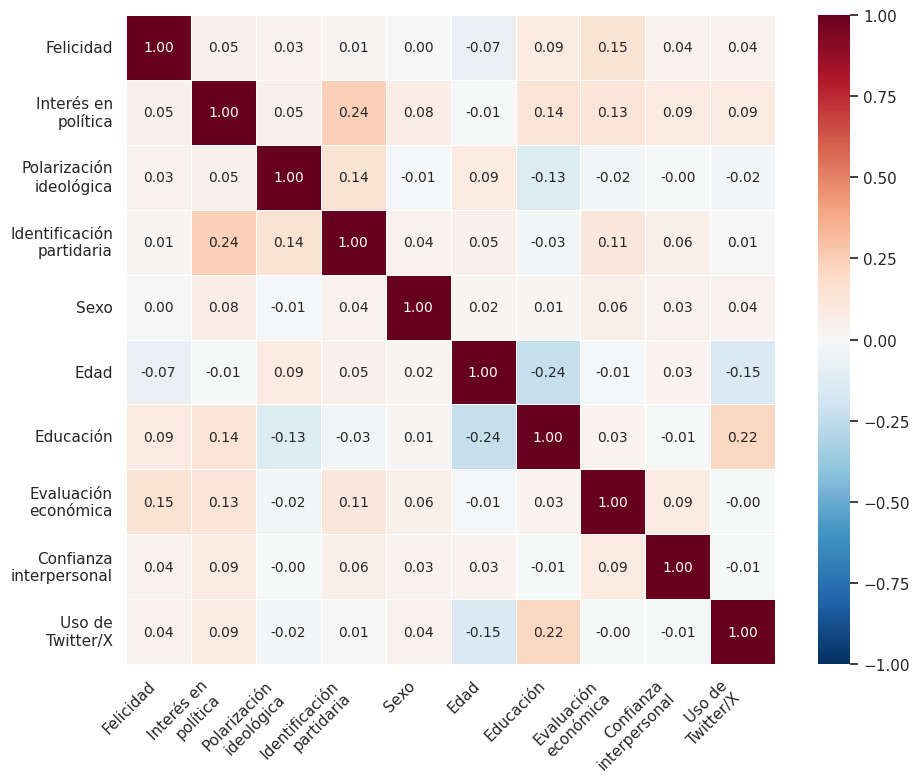

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    "life_satisfaction",
    "interest_politics",
    "left_right_distance",
    "party_id",
    "sex",
    "age",
    "education",
    "econ_country",
    "trust_people",
    "twitter",
]

# Nombres para mostrar
labels = {
    "life_satisfaction": "Felicidad",
    "interest_politics": "Interés en\npolítica",
    "left_right_distance": "Polarización\nideológica",
    "party_id": "Identificación\npartidaria",
    "sex": "Sexo",
    "age": "Edad",
    "education": "Educación",
    "econ_country": "Evaluación\neconómica",
    "trust_people": "Confianza\ninterpersonal",
    "twitter": "Uso de\nTwitter/X",
}

df_corr = master[cols].dropna()

corr = df_corr.corr(method="pearson")
corr = corr.rename(index=labels, columns=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=.5,
    annot_kws={"size": 10}
)

#plt.title("Matriz de correlaciones", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Estandarización

In [23]:
vars_z = [
    "left_right_distance", "life_satisfaction","interest_politics", "age" ,"education" , "econ_country"
    ]

for v in vars_z:
    master[f"{v}_z"] = np.nan

for wave in master["wave"].unique():
    mask = master["wave"] == wave
    for v in vars_z:
        if v in master.columns:
            s = master.loc[mask, v].astype(float)
            mean = s.mean(skipna=True)
            sd = s.std(skipna=True)
            master.loc[mask, f"{v}_z"] = (s - mean) / sd if sd not in [0, None] else np.nan

# Modelos

In [24]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# =========================
# base para regresión
# =========================

df_reg = master.copy()
#df_reg = df_reg[df_reg['wave'] > 2000]

# variables necesarias
vars_needed = [
    "life_satisfaction_z",
    "interest_politics_z",
    "left_right_distance_z",
    "age_z",
    "education_z",
    "econ_country_z",
    "sex",
    "trust_people",
    "wave",
    "city"
]

df_reg = df_reg[vars_needed].copy()

# convertir a numérico
for c in vars_needed:

    df_reg[c] = pd.to_numeric(
        df_reg[c],
        errors="coerce"
    )

# drop missing
df_reg = df_reg.dropna()

print(df_reg.shape)

# =========================
# regresión OLS
# errores clusterizados por ola
# =========================

model = smf.ols(

    formula="""
    life_satisfaction_z ~
    interest_politics_z +
    left_right_distance_z +
    age_z +
    education_z +
    econ_country_z +
    trust_people +
    sex

    """,

    data=df_reg

).fit(

    cov_type="cluster",

    cov_kwds={
        "groups": df_reg["city"]
    }
)

print(model.summary())

(192272, 10)
                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.036
Model:                             OLS   Adj. R-squared:                  0.036
Method:                  Least Squares   F-statistic:                     505.8
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                         15:01:14   Log-Likelihood:            -2.6805e+05
No. Observations:               192272   AIC:                         5.361e+05
Df Residuals:                   192264   BIC:                         5.362e+05
Df Model:                            7                                         
Covariance Type:               cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Interce

In [25]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# =========================
# base para regresión
# =========================

df_reg = master.copy()

vars_needed = [
    "life_satisfaction_z",
    "interest_politics_z",
    "left_right_distance_z",
    "age_z",
    "education_z",
    "wave",
    "econ_country_z",
    "sex",
    "trust_people",
    "city"
]

df_reg = df_reg[vars_needed].copy()

# convertir a numérico
for c in vars_needed:

    df_reg[c] = pd.to_numeric(
        df_reg[c],
        errors="coerce"
    )

# eliminar missing
df_reg = df_reg.dropna()

print(df_reg.shape)

# =========================
# OLS con efectos fijos por ola
# =========================

model = smf.ols(

    formula="""
    life_satisfaction_z ~
    interest_politics_z +
    left_right_distance_z +
    age_z +
    education_z +
    econ_country_z +
    sex +
    trust_people +
    C(wave)
    """,

    data=df_reg

).fit(

    cov_type="cluster",

    cov_kwds={
        "groups": df_reg["city"]
    }
)

print(model.summary())


(192272, 10)
                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.037
Model:                             OLS   Adj. R-squared:                  0.036
Method:                  Least Squares   F-statistic:                     201.1
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                         15:01:15   Log-Likelihood:            -2.6804e+05
No. Observations:               192272   AIC:                         5.361e+05
Df Residuals:                   192252   BIC:                         5.363e+05
Df Model:                           19                                         
Covariance Type:               cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Interce

In [26]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# =========================
# base para regresión
# =========================

df_reg = master.copy()

vars_needed = [
    "life_satisfaction_z",
    "interest_politics_z",
    "left_right_distance_z",
    "age_z",
    "education_z",
    "wave",
    "country",
    "city",
    "econ_country_z",
    "sex",
    "trust_people"

]

df_reg = df_reg[vars_needed].copy()

# convertir numéricas
for c in [
    "life_satisfaction_z",
    "interest_politics_z",
    "left_right_distance_z",
    "age_z",
    "education_z"
]:

    df_reg[c] = pd.to_numeric(
        df_reg[c],
        errors="coerce"
    )

# eliminar missing
df_reg = df_reg.dropna()

print(df_reg.shape)

# =========================
# OLS con FE de ola y país
# =========================

model = smf.ols(

    formula="""
    life_satisfaction_z ~
    interest_politics_z +
    left_right_distance_z +
    age_z +
    education_z +
    econ_country_z +
    sex +
    trust_people +
    C(wave) +
    C(country)
    """,

    data=df_reg

).fit(

    cov_type="cluster",

    cov_kwds={
        "groups": df_reg["city"]
    }
)

print(model.summary())

(192272, 11)
                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.085
Model:                             OLS   Adj. R-squared:                  0.085
Method:                  Least Squares   F-statistic:                     249.4
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                         15:01:18   Log-Likelihood:            -2.6307e+05
No. Observations:               192272   AIC:                         5.262e+05
Df Residuals:                   192235   BIC:                         5.266e+05
Df Model:                           36                                         
Covariance Type:               cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Interce

In [27]:
################### MODELO 6 ################

#df_clean = df_reg.loc[df_reg["wave"] > 2019].copy()
df_clean = df_reg.copy()


df_clean["polar_country_wave_z"] = (
    df_clean
    .groupby(["country","wave"])["left_right_distance_z"]
    .transform("mean")
)

df_clean["polar_within_z"] = (
    df_clean["left_right_distance_z"] - df_clean["polar_country_wave_z"]
)


multinivel = smf.ols(
    """life_satisfaction_z ~ polar_within_z + polar_country_wave_z
             + interest_politics_z
             + interest_politics_z:polar_within_z
             + interest_politics_z:polar_country_wave_z

             + age_z + education_z +econ_country_z + sex + trust_people

             + C(country) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["country"]})

print(multinivel.summary())


                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.085
Model:                             OLS   Adj. R-squared:                  0.085
Method:                  Least Squares   F-statistic:                     56.63
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):           1.20e-11
Time:                         15:01:22   Log-Likelihood:            -2.6305e+05
No. Observations:               192272   AIC:                         5.262e+05
Df Residuals:                   192232   BIC:                         5.266e+05
Df Model:                           39                                         
Covariance Type:               cluster                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 39, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [47]:
################### MODELO 6 con city wave ################

#df_clean = df_reg.loc[df_reg["wave"] > 2019].copy()
df_clean = df_reg.copy()


df_clean["polar_country_wave_z"] = (
    df_clean
    .groupby(["country","wave"])["left_right_distance_z"]
    .transform("mean")
)

df_clean["polar_city_wave_z"] = (
    df_clean
    .groupby(["city","wave"])["left_right_distance_z"]
    .transform("mean")
)

df_clean["polar_within_z"] = (
    df_clean["left_right_distance_z"] - df_clean["polar_country_wave_z"]
)


multinivel = smf.ols(
    """life_satisfaction_z ~ polar_within_z + polar_country_wave_z
             + interest_politics_z
             + interest_politics_z:polar_within_z
             + interest_politics_z:polar_city_wave_z
             + interest_politics_z:polar_country_wave_z

             + age_z + education_z +econ_country_z + sex + trust_people

             + C(country) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["country"]})

print(multinivel.summary())


                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.085
Model:                             OLS   Adj. R-squared:                  0.085
Method:                  Least Squares   F-statistic:                     60.86
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):           6.64e-12
Time:                         15:53:46   Log-Likelihood:            -2.6282e+05
No. Observations:               192094   AIC:                         5.257e+05
Df Residuals:                   192053   BIC:                         5.261e+05
Df Model:                           40                                         
Covariance Type:               cluster                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 40, but rank is 17
  warnings.warn('covariance of constraints does not have full '


# Robustez y otros

In [28]:
################### Ciudad ################
df_clean = df_reg.copy()


df_clean["polar_city_wave_z"] = (
    df_clean
    .groupby(["city","wave"])["left_right_distance_z"]
    .transform("mean")
)

df_clean["polar_within_z"] = (
    df_clean["left_right_distance_z"] - df_clean["polar_city_wave_z"]
)

multinivel = smf.ols(
    """life_satisfaction_z ~ polar_within_z + polar_city_wave_z
             + interest_politics_z
             + interest_politics_z:polar_within_z
             + interest_politics_z:polar_city_wave_z

             + age_z + education_z + econ_country_z + sex + trust_people
             + C(country) + C(wave)""",
    data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["city"]})

print(multinivel.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.085
Model:                             OLS   Adj. R-squared:                  0.085
Method:                  Least Squares   F-statistic:                     235.4
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                         15:01:25   Log-Likelihood:            -2.6304e+05
No. Observations:               192272   AIC:                         5.262e+05
Df Residuals:                   192232   BIC:                         5.266e+05
Df Model:                           39                                         
Covariance Type:               cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

# Colapsar a Nivel Ciudad

In [29]:
# =========================
# 1. colapsar city-wave
# =========================

df_city = (
    df_reg
    .groupby(["country", "city", "wave"])
    .agg({
        "life_satisfaction_z": "mean",
        "left_right_distance_z": "mean",
        "interest_politics_z": "mean",
        "age_z": "mean",
        "education_z": "mean",
        "econ_country_z": "mean",
        "sex": "mean",
        "trust_people": "mean"
    })
    .reset_index()
)


In [30]:
################ Modelo simple a nivel ciudad #############

model_city = smf.ols(
    """
    life_satisfaction_z ~
    left_right_distance_z +
    interest_politics_z +
    age_z +
    education_z +
    econ_country_z +
    sex +
    trust_people +
    C(country) +
    C(wave)
    """,
    data=df_city
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_city["country"]}
)

print(model_city.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.228
Model:                             OLS   Adj. R-squared:                  0.226
Method:                  Least Squares   F-statistic:                     1146.
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):           1.23e-22
Time:                         15:01:25   Log-Likelihood:                -6574.7
No. Observations:                11229   AIC:                         1.322e+04
Df Residuals:                    11192   BIC:                         1.349e+04
Df Model:                           36                                         
Covariance Type:               cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept           

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 36, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [31]:
########### Modelo con Lags a nivel Ciudad ####################


valid_cities = (
    df_city
    .groupby("city")["wave"]
    .nunique()
)

valid_cities = valid_cities[valid_cities >= 6].index

df_city_dyn = df_city[df_city["city"].isin(valid_cities)].copy()


# ordenar panel
df_city_dyn = df_city_dyn.sort_values(["city", "wave"]).copy()

# crear lags
df_city_dyn["polar_lag"] = (
    df_city_dyn
    .groupby("city")["left_right_distance_z"]
    .shift(1)
)

df_city_dyn["life_lag"] = (
    df_city_dyn
    .groupby("city")["life_satisfaction_z"]
    .shift(1)
)

df_city_dyn["interest_lag"] = (
    df_city_dyn
    .groupby("city")["interest_politics_z"]
    .shift(1)
)

# variables del modelo
vars_model = [
    "life_satisfaction_z",
    "polar_lag",
    "life_lag",
    "interest_lag",
    "left_right_distance_z",
    "interest_politics_z",
    "econ_country_z",
    "city",
    "wave",
    "trust_people",
    "sex"
]

# eliminar missings
df_model = df_city_dyn[vars_model].dropna().copy()

# modelo dinámico
model_dyn = smf.ols(
    """
    life_satisfaction_z ~
    polar_lag +
    life_lag +
    interest_lag +

    interest_politics_z +
    left_right_distance_z +

    econ_country_z +
    sex +
    trust_people +


    C(wave)
    """,
    data=df_model
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_model["city"]}
)

print(model_dyn.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.158
Model:                             OLS   Adj. R-squared:                  0.155
Method:                  Least Squares   F-statistic:                     30.39
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):           1.85e-72
Time:                         15:01:25   Log-Likelihood:                -2348.0
No. Observations:                 4078   AIC:                             4736.
Df Residuals:                     4058   BIC:                             4862.
Df Model:                           19                                         
Covariance Type:               cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept           

In [32]:
################# Modelo con Lags y change a nivel Ciudad ####################


# ordenar
df_city_dyn = df_city_dyn.sort_values(["city", "wave"]).copy()

# lags
df_city_dyn["life_lag"] = (
    df_city_dyn
    .groupby("city")["life_satisfaction_z"]
    .shift(1)
)

df_city_dyn["polar_lag"] = (
    df_city_dyn
    .groupby("city")["left_right_distance_z"]
    .shift(1)
)

df_city_dyn["interest_lag"] = (
    df_city_dyn
    .groupby("city")["interest_politics_z"]
    .shift(1)
)

# cambios
df_city_dyn["polar_change"] = (
    df_city_dyn
    .groupby("city")["left_right_distance_z"]
    .diff()
)

df_city_dyn["interest_change"] = (
    df_city_dyn
    .groupby("city")["interest_politics_z"]
    .diff()
)

# base limpia para el modelo
vars_model = [
    "life_satisfaction_z",
    "life_lag",
    "polar_lag",
    "interest_lag",
    "polar_change",
    "interest_change",
    "interest_politics_z",
    "left_right_distance_z",
    "econ_country_z",
    "sex",
    "trust_people",
    "wave",
    "city",
    "country"
]

df_model = (
    df_city_dyn[vars_model]
    .dropna()
    .copy()
)

# modelo
model_dyn2 = smf.ols(
    """
    life_satisfaction_z ~
    life_lag +


    polar_change +
    interest_change +

    interest_politics_z +
    left_right_distance_z +

    econ_country_z +
    sex+
    trust_people +
    C(wave)+
    C(country)
    """,
    data=df_model
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_model["city"]}
)

print(model_dyn2.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.305
Model:                             OLS   Adj. R-squared:                  0.299
Method:                  Least Squares   F-statistic:                     57.08
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):          2.28e-158
Time:                         15:01:25   Log-Likelihood:                -1957.1
No. Observations:                 4078   AIC:                             3988.
Df Residuals:                     4041   BIC:                             4222.
Df Model:                           36                                         
Covariance Type:               cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept           

# Colapsar a nivel País

In [33]:
# =========================
# 1. colapsar country-wave
# =========================

df_country = (
    df_reg
    .groupby(["country", "wave"])
    .agg({
        "life_satisfaction_z": "mean",
        "left_right_distance_z": "mean",
        "interest_politics_z": "mean",
        "age_z": "mean",
        "education_z": "mean",
        "econ_country_z": "mean",
        "sex": "mean",
        "trust_people": "mean"
    })
    .reset_index()
)

In [34]:
############## Modelo simple a nivel país #########################


model_country = smf.ols(
    """
    life_satisfaction_z ~
    left_right_distance_z +
    interest_politics_z +
    age_z +
    education_z +
    econ_country_z +
    sex +
    trust_people +
    C(country) +
    C(wave)
    """,
    data=df_country
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_country["country"]}
)

print(model_country.summary())


                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.734
Model:                             OLS   Adj. R-squared:                  0.684
Method:                  Least Squares   F-statistic:                     4.496
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):            0.00171
Time:                         15:01:25   Log-Likelihood:                 129.84
No. Observations:                  228   AIC:                            -185.7
Df Residuals:                      191   BIC:                            -58.78
Df Model:                           36                                         
Covariance Type:               cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept           

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 36, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [35]:
########### Modelo con Lags - Nivel País ####################

# quedarnos con países con suficientes waves
valid_countries = (
    df_country
    .groupby("country")["wave"]
    .nunique()
)

valid_countries = valid_countries[valid_countries >= 6].index

df_country_dyn = (
    df_country[df_country["country"].isin(valid_countries)]
    .copy()
)

# ordenar panel
df_country_dyn = (
    df_country_dyn
    .sort_values(["country", "wave"])
    .copy()
)

# crear lags
df_country_dyn["polar_lag"] = (
    df_country_dyn
    .groupby("country")["left_right_distance_z"]
    .shift(1)
)

df_country_dyn["life_lag"] = (
    df_country_dyn
    .groupby("country")["life_satisfaction_z"]
    .shift(1)
)

df_country_dyn["interest_lag"] = (
    df_country_dyn
    .groupby("country")["interest_politics_z"]
    .shift(1)
)

# variables del modelo
vars_model = [
    "life_satisfaction_z",
    "polar_lag",
    "life_lag",
    "interest_lag",
    "interest_politics_z",
    "econ_country_z",
    "country",
    "wave",
    "trust_people",
    "sex"
]

# eliminar missings
df_model = (
    df_country_dyn[vars_model]
    .dropna()
    .copy()
)

# modelo dinámico
model_dyn_country = smf.ols(
    """
    life_satisfaction_z ~
    polar_lag +
    life_lag +
    interest_lag +
    econ_country_z +
    sex +
    trust_people +
    C(wave)
    """,
    data=df_model
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_model["country"]}
)

print(model_dyn_country.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.644
Model:                             OLS   Adj. R-squared:                  0.612
Method:                  Least Squares   F-statistic:                     781.4
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):           3.16e-21
Time:                         15:01:25   Log-Likelihood:                 88.192
No. Observations:                  210   AIC:                            -140.4
Df Residuals:                      192   BIC:                            -80.14
Df Model:                           17                                         
Covariance Type:               cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1438      

In [36]:
################# Modelo con Lags y Change - Nivel País ####################

# ordenar
df_country_dyn = df_country_dyn.sort_values(["country", "wave"]).copy()

# lags
df_country_dyn["life_lag"] = (
    df_country_dyn
    .groupby("country")["life_satisfaction_z"]
    .shift(1)
)

df_country_dyn["polar_lag"] = (
    df_country_dyn
    .groupby("country")["left_right_distance_z"]
    .shift(1)
)

df_country_dyn["interest_lag"] = (
    df_country_dyn
    .groupby("country")["interest_politics_z"]
    .shift(1)
)

# cambios
df_country_dyn["polar_change"] = (
    df_country_dyn
    .groupby("country")["left_right_distance_z"]
    .diff()
)

df_country_dyn["interest_change"] = (
    df_country_dyn
    .groupby("country")["interest_politics_z"]
    .diff()
)

# base limpia para el modelo
vars_model = [
    "life_satisfaction_z",
    "life_lag",

    "polar_change",
    "interest_change",
    "econ_country_z",
    "sex",
    "trust_people",
    "wave",
    "country"
]

df_model = (
    df_country_dyn[vars_model]
    .dropna()
    .copy()
)

# modelo
model_dyn2_country = smf.ols(
    """
    life_satisfaction_z ~
    life_lag +

    polar_change +
    interest_change +
    econ_country_z +
    sex +
    trust_people +
    C(wave)
    """,
    data=df_model
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_model["country"]}
)

print(model_dyn2_country.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.621
Model:                             OLS   Adj. R-squared:                  0.587
Method:                  Least Squares   F-statistic:                     50.23
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):           3.22e-11
Time:                         15:01:26   Log-Likelihood:                 81.553
No. Observations:                  210   AIC:                            -127.1
Df Residuals:                      192   BIC:                            -66.86
Df Model:                           17                                         
Covariance Type:               cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0109      